# 08 — IBP-Trained MLP

Trains the same `MnistMlp` (784→128→64→10) using a *certified* training objective:
Interval-Bound-Propagation (IBP) worst-case loss, mixed with the standard cross-entropy on clean inputs.

**Loss:**
$$\mathcal{L} = \kappa\,\mathrm{CE}(z_{\mathrm{clean}},y) + (1-\kappa)\,\mathrm{CE}(z_{\mathrm{worst}},y)$$
where $z_{\mathrm{worst}}[c]=z_u[c]$ for $c\neq y$ and $z_{\mathrm{worst}}[y]=z_l[y]$ — i.e. the worst-case logits over the IBP box.

**Schedule (50 epochs):**
- Epochs 1–15: $\varepsilon$ linear $0\to 0.03$, $\kappa$ linear $1.0\to 0.5$
- Epochs 16–50: $\varepsilon=0.03$, $\kappa=0.5$
- Adam lr=5e-4, batch=128.

**Targets (must be met before downstream pipeline runs):**
- Clean test accuracy ≥ 96%.
- IBP-verified rate at $\varepsilon=0.03$ on the 100-sample split ≥ 60%.

If the IBP-verified rate is < 40% the notebook auto-doubles the schedule to 100 epochs and retries (per spec).

Saves to `runs/mlp_ibp_trained/model.pt`.

In [2]:
# ── Colab bootstrap ─────────────────────────────────────────────────────────────
# Mounts Drive (Colab) or noop (local), cd's into the project folder, and
# self-generates `assets/splits/mnist_eval_1000.json` if it's not present.
# colab_bootstrap_v1
import os
from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/thesis-formal-verification")
    PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
    os.chdir(PROJECT_ROOT)
    print(f"[colab] working dir: {PROJECT_ROOT}")
except ImportError:
    print(f"[local] working dir: {Path.cwd()}")

# Self-generate the 1000-sample evaluation split if missing
import json, random
split_100  = Path("assets/splits/mnist_eval_100.json")
split_1000 = Path("assets/splits/mnist_eval_1000.json")
if not split_1000.exists():
    split_100.parent.mkdir(parents=True, exist_ok=True)
    seed = 1234
    if split_100.exists():
        idx100 = json.loads(split_100.read_text(encoding="utf-8"))["indices"]
    else:
        idx100 = random.Random(seed).sample(range(10_000), 100)
        split_100.write_text(json.dumps({"seed": seed, "indices": idx100}, indent=2) + "\n", encoding="utf-8")
    remaining = [i for i in range(10_000) if i not in set(idx100)]
    extra = random.Random(seed).sample(remaining, 900)
    indices_1000 = idx100 + extra
    assert indices_1000[:100] == idx100
    split_1000.write_text(json.dumps({"seed": seed, "indices": indices_1000}, indent=2) + "\n", encoding="utf-8")
    print(f"[bootstrap] wrote {split_1000} ({len(indices_1000)} indices)")
else:
    print(f"[bootstrap] OK {split_1000}  ({len(json.loads(split_1000.read_text(encoding='utf-8'))['indices'])} indices)")


Mounted at /content/drive
[colab] working dir: /content/drive/MyDrive/thesis-formal-verification
[bootstrap] OK assets/splits/mnist_eval_1000.json  (1000 indices)


In [3]:
!pip install -q torch torchvision numpy pandas pyyaml tqdm

## 1 — Library code (model, data, IBP, training loop)

In [4]:
from __future__ import annotations

import json
import os
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Tuple

import numpy as np
import torch
import torch.nn.functional as F
from torch import Tensor, nn, optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from tqdm import tqdm


# ── Reproducibility ────────────────────────────────────────────────────────────
def set_seed(seed: int, deterministic: bool = True) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.use_deterministic_algorithms(True, warn_only=True)


# ── Data ───────────────────────────────────────────────────────────────────────
def get_mnist_datasets(data_dir: str | Path = "data"):
    data_dir = Path(data_dir)
    tfm = transforms.ToTensor()
    train_ds = datasets.MNIST(root=str(data_dir), train=True,  download=True, transform=tfm)
    test_ds  = datasets.MNIST(root=str(data_dir), train=False, download=True, transform=tfm)
    return train_ds, test_ds


def make_loader(dataset, batch_size: int, shuffle: bool, num_workers: int, seed: int):
    gen = torch.Generator()
    gen.manual_seed(int(seed))
    return DataLoader(
        dataset,
        batch_size=int(batch_size),
        shuffle=bool(shuffle),
        num_workers=int(num_workers),
        generator=gen,
        drop_last=False,
        pin_memory=False,
    )


# ── Eval split ─────────────────────────────────────────────────────────────────
@dataclass(frozen=True)
class Split:
    seed: int
    indices: list


def load_split(path) -> Split:
    obj = json.loads(Path(path).read_text(encoding="utf-8"))
    return Split(seed=int(obj["seed"]), indices=[int(i) for i in obj["indices"]])


# ── Model ──────────────────────────────────────────────────────────────────────
class MnistMlp(nn.Module):
    def __init__(self, in_dim: int = 784, h1: int = 128, h2: int = 64, num_classes: int = 10):
        super().__init__()
        self.in_dim = int(in_dim)
        self.h1 = int(h1)
        self.h2 = int(h2)
        self.num_classes = int(num_classes)
        self.fc1 = nn.Linear(self.in_dim, self.h1)
        self.fc2 = nn.Linear(self.h1, self.h2)
        self.fc3 = nn.Linear(self.h2, self.num_classes)
        self.relu = nn.ReLU()

    def forward(self, x: Tensor) -> Tensor:
        if x.ndim == 4:
            x = x.view(x.shape[0], -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

    def linear_layers(self):
        return [self.fc1, self.fc2, self.fc3]


# ── Checkpoint I/O (matches src/nnverify.models.io) ───────────────────────────
@dataclass(frozen=True)
class CheckpointMeta:
    model_type: str
    model_kwargs: dict
    run_name: str


def save_checkpoint(path, model, meta: CheckpointMeta, metrics=None):
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "meta": asdict(meta),
        "model_state_dict": model.state_dict(),
        "metrics": metrics or {},
    }
    torch.save(payload, str(p))
    p.with_suffix(".meta.json").write_text(
        json.dumps(payload["meta"], indent=2) + "\n", encoding="utf-8"
    )


print("Library code loaded")

Library code loaded


## 2 — Differentiable IBP forward pass

This is *almost* the same as `src/nnverify/verifiers/milp/bounds_ibp.py` but written
in batched form and with autograd-tracked tensors so we can backprop through it.

In [5]:
def ibp_forward_logits(model: MnistMlp, x: Tensor, eps: float) -> Tuple[Tensor, Tensor]:
    """Batched IBP propagation through the MLP.

    Returns ``(z_l, z_u)`` of shape ``(B, num_classes)`` — lower / upper bounds
    on the output logits over the L_inf box of radius ``eps`` around each x,
    clipped to [0, 1] per pixel.
    """
    if x.ndim == 4:
        x = x.view(x.shape[0], -1)
    h_l = torch.clamp(x - float(eps), 0.0, 1.0)
    h_u = torch.clamp(x + float(eps), 0.0, 1.0)

    linears = model.linear_layers()
    for li, layer in enumerate(linears):
        W = layer.weight
        b = layer.bias
        W_pos = torch.clamp(W, min=0.0)
        W_neg = torch.clamp(W, max=0.0)
        a_l = h_l @ W_pos.t() + h_u @ W_neg.t() + b
        a_u = h_u @ W_pos.t() + h_l @ W_neg.t() + b
        is_last = li == len(linears) - 1
        if is_last:
            return a_l, a_u
        h_l = torch.relu(a_l)
        h_u = torch.relu(a_u)
    raise RuntimeError("Unreachable: model has no layers?")


def worst_case_logits(z_l: Tensor, z_u: Tensor, y: Tensor) -> Tensor:
    """Build the worst-case logits used in IBP-style certified loss.

    For each c != y use upper bound z_u[c] (an attacker maximises non-target logits);
    for c == y use lower bound z_l[y] (an attacker minimises the true class logit).
    """
    z_worst = z_u.clone()
    idx = torch.arange(z_l.shape[0], device=z_l.device)
    z_worst[idx, y] = z_l[idx, y]
    return z_worst


@torch.no_grad()
def ibp_verified_rate(model: MnistMlp, loader, eps: float, device: str) -> float:
    """Fraction of samples for which IBP certifies robustness at ``eps``."""
    model.eval()
    n_ver = 0
    n_total = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        z_l, z_u = ibp_forward_logits(model, x, eps=float(eps))
        idx = torch.arange(z_l.shape[0], device=device)
        margin_lower = z_l[idx, y].unsqueeze(1) - z_u  # B x C
        margin_lower[idx, y] = float("inf")             # ignore self-class
        verified = (margin_lower.min(dim=1).values > 0)
        n_ver += int(verified.sum().item())
        n_total += int(y.numel())
    return n_ver / max(n_total, 1)


@torch.no_grad()
def eval_accuracy(model, loader, device):
    model.eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(dim=1)
        correct += int((pred == y).sum().item())
        total += int(y.numel())
    return correct / max(total, 1)


print("IBP utilities defined")

IBP utilities defined


## 3 — Configuration

In [6]:
# ── Hyperparameters ────────────────────────────────────────────────────────────
SEED         = 1234
DATA_DIR     = "data"
RUN_NAME     = "mlp_ibp_trained"
BATCH_SIZE   = 128
LR           = 5e-4
WEIGHT_DECAY = 0.0
NUM_WORKERS  = 0
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

EPS_FINAL    = 0.03
WARMUP_EPOCHS = 15
TOTAL_EPOCHS  = 50
KAPPA_START   = 1.0
KAPPA_FINAL   = 0.5

# Validation targets (per spec)
CLEAN_ACC_TARGET = 0.96
IBP_VERIFIED_TARGET = 0.60
IBP_VERIFIED_RETRY_THRESHOLD = 0.40   # if below this, retry with 2x epochs
EVAL_SUBSET_PATH = "assets/splits/mnist_eval_100.json"

set_seed(SEED)
print(f"Device: {DEVICE} | epochs: {TOTAL_EPOCHS} (warmup {WARMUP_EPOCHS}) | eps_final: {EPS_FINAL}")

Device: cuda | epochs: 50 (warmup 15) | eps_final: 0.03


## 4 — Schedule helpers

In [7]:
def eps_kappa_at_epoch(epoch_idx_1based: int, warmup_epochs: int, total_epochs: int,
                       eps_final: float, kappa_start: float, kappa_final: float) -> Tuple[float, float]:
    """Linear ramp during warmup; constant afterwards.

    epoch_idx_1based ranges from 1..total_epochs.
    """
    e = int(epoch_idx_1based)
    W = max(int(warmup_epochs), 1)
    if e <= W:
        # progress in [1/W, 1]
        p = e / float(W)
        eps_t   = float(eps_final) * p
        kappa_t = float(kappa_start) + (float(kappa_final) - float(kappa_start)) * p
    else:
        eps_t   = float(eps_final)
        kappa_t = float(kappa_final)
    return eps_t, kappa_t


# Quick sanity-print of the full schedule
print(f"{'epoch':>5} {'eps':>8} {'kappa':>8}")
for e in [1, 5, 10, 15, 16, 25, 50]:
    eps_t, k_t = eps_kappa_at_epoch(e, WARMUP_EPOCHS, TOTAL_EPOCHS, EPS_FINAL, KAPPA_START, KAPPA_FINAL)
    print(f"{e:>5} {eps_t:>8.4f} {k_t:>8.4f}")

epoch      eps    kappa
    1   0.0020   0.9667
    5   0.0100   0.8333
   10   0.0200   0.6667
   15   0.0300   0.5000
   16   0.0300   0.5000
   25   0.0300   0.5000
   50   0.0300   0.5000


## 5 — Training loop

Per-batch loss is
$$\mathcal{L}(B) = \kappa\,\mathrm{CE}(z_{\mathrm{clean}},y) + (1-\kappa)\,\mathrm{CE}(z_{\mathrm{worst}},y).$$
We log clean accuracy on the test set and IBP-verified rate at $\varepsilon_t$ each epoch.

In [8]:
def train_ibp(
    *,
    seed: int,
    data_dir,
    device: str,
    batch_size: int,
    lr: float,
    weight_decay: float,
    total_epochs: int,
    warmup_epochs: int,
    eps_final: float,
    kappa_start: float,
    kappa_final: float,
    eval_subset_path,
) -> Tuple[MnistMlp, dict]:
    set_seed(seed)

    train_ds, test_ds = get_mnist_datasets(data_dir)
    train_loader = make_loader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0, seed=seed)
    test_loader  = make_loader(test_ds,  batch_size=512, shuffle=False, num_workers=0, seed=seed)

    eval_split = load_split(eval_subset_path)
    eval_sub_loader = DataLoader(
        Subset(test_ds, eval_split.indices), batch_size=128, shuffle=False, num_workers=0
    )

    model = MnistMlp(in_dim=784, h1=128, h2=64, num_classes=10).to(device)
    opt   = optim.Adam(model.parameters(), lr=float(lr), weight_decay=float(weight_decay))

    metrics = {
        "epochs": [],
        "hp": {
            "seed": seed, "batch_size": batch_size, "lr": lr, "weight_decay": weight_decay,
            "total_epochs": total_epochs, "warmup_epochs": warmup_epochs,
            "eps_final": eps_final, "kappa_start": kappa_start, "kappa_final": kappa_final,
        },
    }
    t0 = time.time()

    for epoch in range(1, int(total_epochs) + 1):
        eps_t, kappa_t = eps_kappa_at_epoch(
            epoch, warmup_epochs, total_epochs, eps_final, kappa_start, kappa_final
        )

        model.train()
        running_clean_loss = 0.0
        running_robust_loss = 0.0
        running_total_loss = 0.0
        n_seen = 0
        correct_clean = 0

        epoch_start = time.time()
        pbar = tqdm(train_loader, desc=f"ep {epoch:>2}/{total_epochs}  eps={eps_t:.4f} k={kappa_t:.3f}", leave=False)
        for x, y in pbar:
            x = x.to(device)
            y = y.to(device)
            opt.zero_grad(set_to_none=True)

            z_clean = model(x)
            ce_clean = F.cross_entropy(z_clean, y)

            if eps_t > 0.0:
                z_l, z_u = ibp_forward_logits(model, x, eps=eps_t)
                z_worst = worst_case_logits(z_l, z_u, y)
                ce_robust = F.cross_entropy(z_worst, y)
            else:
                ce_robust = ce_clean.detach() * 0.0

            loss = float(kappa_t) * ce_clean + (1.0 - float(kappa_t)) * ce_robust
            loss.backward()
            opt.step()

            bs = int(y.numel())
            running_clean_loss  += float(ce_clean.item()) * bs
            running_robust_loss += float(ce_robust.item()) * bs
            running_total_loss  += float(loss.item()) * bs
            correct_clean       += int((z_clean.argmax(1) == y).sum().item())
            n_seen              += bs

        train_clean_loss  = running_clean_loss  / max(n_seen, 1)
        train_robust_loss = running_robust_loss / max(n_seen, 1)
        train_total_loss  = running_total_loss  / max(n_seen, 1)
        train_clean_acc   = correct_clean / max(n_seen, 1)

        # Eval
        test_clean_acc = eval_accuracy(model, test_loader, device=device)
        # IBP-verified rate at the eps used this epoch (curriculum view)
        ibp_ver_at_curr_eps = ibp_verified_rate(model, eval_sub_loader, eps=eps_t, device=device)
        # IBP-verified rate at the FINAL eps (the target we want to hit at the end)
        ibp_ver_at_final_eps = ibp_verified_rate(model, eval_sub_loader, eps=eps_final, device=device)

        metrics["epochs"].append({
            "epoch": epoch,
            "eps_t": eps_t,
            "kappa_t": kappa_t,
            "train_clean_loss":  train_clean_loss,
            "train_robust_loss": train_robust_loss,
            "train_total_loss":  train_total_loss,
            "train_clean_acc":   train_clean_acc,
            "test_clean_acc":    test_clean_acc,
            "ibp_ver_at_curr_eps":  ibp_ver_at_curr_eps,
            "ibp_ver_at_final_eps": ibp_ver_at_final_eps,
            "epoch_time_s":      time.time() - epoch_start,
        })
        print(
            f"ep={epoch:>2}/{total_epochs} eps={eps_t:.4f} k={kappa_t:.3f} "
            f"train_loss(c/r/total)={train_clean_loss:.4f}/{train_robust_loss:.4f}/{train_total_loss:.4f} "
            f"test_acc={test_clean_acc:.4f} "
            f"ibp_ver@eps_t={ibp_ver_at_curr_eps:.3f} ibp_ver@eps_final={ibp_ver_at_final_eps:.3f}"
        )

    metrics["total_time_s"] = time.time() - t0
    return model, metrics


print("train_ibp() defined")

train_ibp() defined


## 6 — Run training (with auto-retry at 2× epochs if IBP-verified rate is too low)

In [9]:
def run_with_retry():
    epochs = TOTAL_EPOCHS
    warmup = WARMUP_EPOCHS
    for attempt in (1, 2):
        print(f"\n=== Attempt {attempt}: total_epochs={epochs}  warmup_epochs={warmup} ===")
        model, metrics = train_ibp(
            seed=SEED,
            data_dir=DATA_DIR,
            device=DEVICE,
            batch_size=BATCH_SIZE,
            lr=LR,
            weight_decay=WEIGHT_DECAY,
            total_epochs=epochs,
            warmup_epochs=warmup,
            eps_final=EPS_FINAL,
            kappa_start=KAPPA_START,
            kappa_final=KAPPA_FINAL,
            eval_subset_path=EVAL_SUBSET_PATH,
        )
        last = metrics["epochs"][-1]
        ver = float(last["ibp_ver_at_final_eps"])
        clean = float(last["test_clean_acc"])
        print(f"\nFinal: clean_test_acc={clean:.4f}  ibp_ver@eps_final={ver:.4f}")
        if ver >= IBP_VERIFIED_RETRY_THRESHOLD or attempt == 2:
            return model, metrics
        print(f"IBP-verified rate {ver:.3f} < {IBP_VERIFIED_RETRY_THRESHOLD:.3f} "
              "— doubling epoch budget and retrying.")
        epochs = epochs * 2
        warmup = warmup * 2
    raise RuntimeError("unreachable")


model, metrics = run_with_retry()


=== Attempt 1: total_epochs=50  warmup_epochs=15 ===


ep= 1/50 eps=0.0020 k=0.967 train_loss(c/r/total)=0.5440/0.8606/0.5546 test_acc=0.9247 ibp_ver@eps_t=0.830 ibp_ver@eps_final=0.000


ep= 2/50 eps=0.0040 k=0.933 train_loss(c/r/total)=0.2278/0.7466/0.2624 test_acc=0.9457 ibp_ver@eps_t=0.820 ibp_ver@eps_final=0.000


ep= 3/50 eps=0.0060 k=0.900 train_loss(c/r/total)=0.1735/0.7026/0.2264 test_acc=0.9544 ibp_ver@eps_t=0.850 ibp_ver@eps_final=0.050


ep= 4/50 eps=0.0080 k=0.867 train_loss(c/r/total)=0.1450/0.6198/0.2083 test_acc=0.9603 ibp_ver@eps_t=0.860 ibp_ver@eps_final=0.090


...

ep=46/50 eps=0.0300 k=0.500 train_loss(c/r/total)=0.0295/0.1371/0.0833 test_acc=0.9825 ibp_ver@eps_t=0.940 ibp_ver@eps_final=0.940


ep=47/50 eps=0.0300 k=0.500 train_loss(c/r/total)=0.0287/0.1350/0.0819 test_acc=0.9832 ibp_ver@eps_t=0.940 ibp_ver@eps_final=0.940


ep=48/50 eps=0.0300 k=0.500 train_loss(c/r/total)=0.0283/0.1330/0.0806 test_acc=0.9836 ibp_ver@eps_t=0.940 ibp_ver@eps_final=0.940


ep=49/50 eps=0.0300 k=0.500 train_loss(c/r/total)=0.0277/0.1311/0.0794 test_acc=0.9834 ibp_ver@eps_t=0.920 ibp_ver@eps_final=0.920


ep=50/50 eps=0.0300 k=0.500 train_loss(c/r/total)=0.0270/0.1293/0.0781 test_acc=0.9836 ibp_ver@eps_t=0.940 ibp_ver@eps_final=0.940

Final: clean_test_acc=0.9836  ibp_ver@eps_final=0.9400


## 7 — Save checkpoint and validate against targets

The checkpoint format matches `src/nnverify/models/io.py`, so `02_attack_pgd`,
`03_verify_milp`, and `07_abcrown_baseline` can load it without changes.

In [10]:
out_dir   = Path("runs") / RUN_NAME
ckpt_path = out_dir / "model.pt"
meta = CheckpointMeta(
    model_type="mlp",
    model_kwargs={"in_dim": 784, "h1": 128, "h2": 64, "num_classes": 10},
    run_name=RUN_NAME,
)
save_checkpoint(ckpt_path, model.cpu(), meta=meta, metrics=metrics)
(out_dir / "metrics.json").write_text(json.dumps(metrics, indent=2) + "\n", encoding="utf-8")

last = metrics["epochs"][-1]
clean_acc = float(last["test_clean_acc"])
ibp_ver   = float(last["ibp_ver_at_final_eps"])

print(f"Saved: {ckpt_path}")
print(f"Final clean test accuracy        : {clean_acc:.4f}    (target ≥ {CLEAN_ACC_TARGET:.2f})")
print(f"Final IBP-verified rate @eps={EPS_FINAL}: {ibp_ver:.4f}    (target ≥ {IBP_VERIFIED_TARGET:.2f})")

# Soft-fail: warn rather than abort (downstream notebooks may still want to use the checkpoint).
if clean_acc < CLEAN_ACC_TARGET:
    print(f"\n[WARN] clean accuracy {clean_acc:.4f} below target {CLEAN_ACC_TARGET:.2f}")
if ibp_ver < IBP_VERIFIED_TARGET:
    print(f"[WARN] IBP-verified rate {ibp_ver:.4f} below target {IBP_VERIFIED_TARGET:.2f}")

OSError: [Errno 107] Transport endpoint is not connected: 'runs/mlp_ibp_trained'

## 8 — Training curves (sanity)

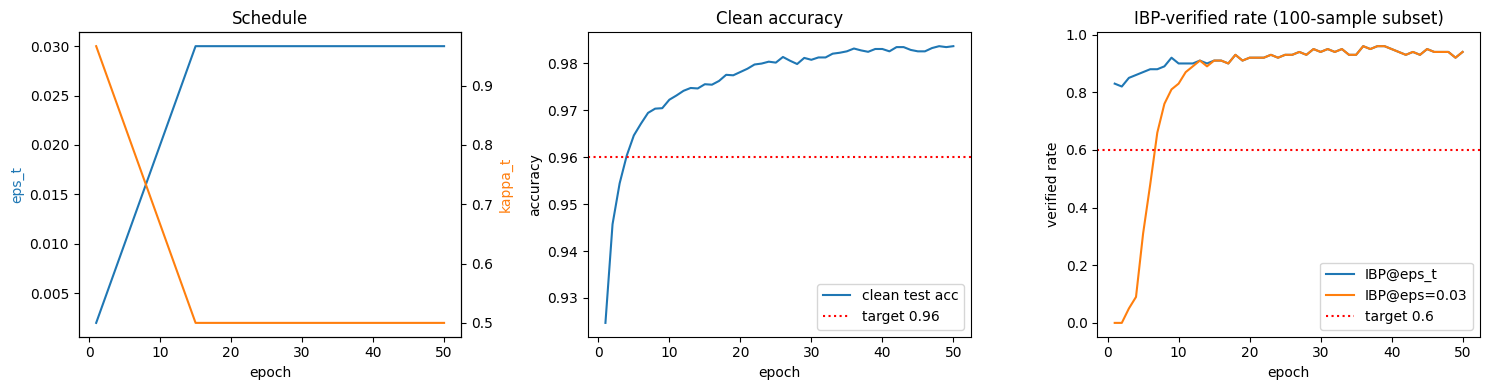

In [13]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    !pip install -q matplotlib
    import matplotlib.pyplot as plt

epochs   = [m["epoch"] for m in metrics["epochs"]]
clean    = [m["test_clean_acc"]        for m in metrics["epochs"]]
ver_curr = [m["ibp_ver_at_curr_eps"]   for m in metrics["epochs"]]
ver_fin  = [m["ibp_ver_at_final_eps"]  for m in metrics["epochs"]]
eps_curve= [m["eps_t"]                 for m in metrics["epochs"]]
kap_curve= [m["kappa_t"]               for m in metrics["epochs"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(epochs, eps_curve, label="eps_t", color="tab:blue")
ax2 = axes[0].twinx()
ax2.plot(epochs, kap_curve, label="kappa_t", color="tab:orange")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("eps_t", color="tab:blue"); ax2.set_ylabel("kappa_t", color="tab:orange")
axes[0].set_title("Schedule")

axes[1].plot(epochs, clean, label="clean test acc")
axes[1].axhline(CLEAN_ACC_TARGET, color="red", ls=":", label=f"target {CLEAN_ACC_TARGET}")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].set_title("Clean accuracy"); axes[1].legend()

axes[2].plot(epochs, ver_curr, label="IBP@eps_t")
axes[2].plot(epochs, ver_fin,  label=f"IBP@eps={EPS_FINAL}")
axes[2].axhline(IBP_VERIFIED_TARGET, color="red", ls=":", label=f"target {IBP_VERIFIED_TARGET}")
axes[2].set_xlabel("epoch"); axes[2].set_ylabel("verified rate"); axes[2].set_title("IBP-verified rate (100-sample subset)"); axes[2].legend()

plt.tight_layout()
plt.show()

In [12]:
import os, json                                                                                                                          
from pathlib import Path
from google.colab import drive                                                                                                         

# Force-remount Drive (the stale mount caused the error)
try:
    drive.flush_and_unmount()
except Exception as e:
    print(f"unmount: {e}")
drive.mount("/content/drive", force_remount=True)

ROOT = Path("/content/drive/MyDrive/thesis-formal-verification")
ROOT.mkdir(parents=True, exist_ok=True)
os.chdir(ROOT)
print("cwd:", os.getcwd())

# Try to save whatever's in memory. If the kernel still holds `model`/`metrics`,
# we recover the run without retraining.
try:
    _ = model  # NameError if kernel state is gone
    out_dir = ROOT / "runs" / "mlp_ibp_trained"
    out_dir.mkdir(parents=True, exist_ok=True)
    try:
        meta_obj = meta
    except NameError:
        meta_obj = CheckpointMeta(
            model_type="mlp",
            model_kwargs={"in_dim": 784, "h1": 128, "h2": 64, "num_classes": 10},
            run_name="mlp_ibp_trained",
        )
    try:
        metrics_obj = metrics
    except NameError:
        metrics_obj = {"note": "recovered after Drive disconnect; metrics dict was lost"}
    save_checkpoint(out_dir / "model.pt", model.cpu(), meta=meta_obj, metrics=metrics_obj)
    (out_dir / "metrics.json").write_text(json.dumps(metrics_obj, indent=2) + "\n", encoding="utf-8")
    print(f"saved {out_dir / 'model.pt'}")
except NameError:
    print("kernel state is gone — need to retrain. Run All from top after this cell.")

Mounted at /content/drive
cwd: /content/drive/MyDrive/thesis-formal-verification
saved /content/drive/MyDrive/thesis-formal-verification/runs/mlp_ibp_trained/model.pt
